# Neural Networks for Data Science Applications
## End-of-term homework: Recurrent neural networks and autoregressive modelling

**Name**: *Francesco Lazzari*

**Matricola**: *1917922*

> ✍ Upload the completed notebook **at least two days** before your expected exam's date on the Google Classroom page. For example, for the **January 20th** session, you should upload it by **January 17th, 23:59 Rome time**.

In [1]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
import numpy as np
from functools import partial
from typing import Tuple, Dict, Any, Optional
from tqdm import tqdm
import pandas as pd
from tokenizers import Tokenizer, models, pre_tokenizers, trainers, decoders
from transformers import PreTrainedTokenizerFast
import pickle
import re

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Instructions

1. The homework is divided into three exercises. The first two (**10 points**) are mandatory for everyone. The third one (**5 points**) is mandatory only if you have not submitted the first homework or if you want to increase the mark.
2. If you score well on the project but poorly on the oral, the grade can be kept for the entire academic year (up to October 2025).

**IMPORTANT - read carefully before starting**:

> 🟨 *External material*: if you use any external material or inspiration for the code, reference it *explicitly* in the corresponding cell. For the textual descriptions, copy-paste *is not allowed*. <ins>Not following these two points is an immediate 0 mark</ins>. **Same goes for LLM-generated material**.

> 🔵 *Grammar*: for the textual descriptions, I will remove points for too many grammatical or textual errors. Please try to be precise and provide nice-to-read descriptions, like if you were writing a report.

> 🟥 *Vectorization and JAX*: the homework must be done _fully in JAX_ (no external libraries) and vectorizing the code as much as possible (e.g., do not loop explicitly over the batch dimension).

> 🟪 *Math*: you can also use LaTeX in Markdown if you need to write equations or if you need generic math notation.

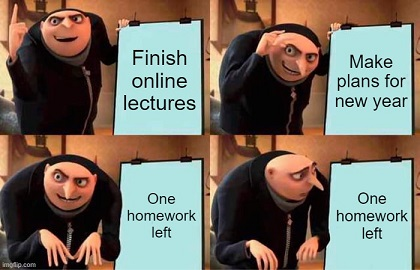

## Warmup: Data loading

For this part, select a dataset that is adequate for an autoregressive modelling task, keeping in mind task complexity with respect to the available hardware. Alternatively, take a generic dataset and transform it in a suitable way. Some examples (non exhaustive list):

1. Any text dataset can be converted to a next-token prediction dataset. You are free to use an existing tokenizer or train the tokenizer from scratch.
2. Time series are also naturally convertible to autoregressive scenarios.
3. For images you can convert them in multiple ways, e.g., as a sequence of pixels, as a sequence of patches (as in ViTs), as a sequence of bytes...
4. Other types of data, such as audio, graphs, DNA sequences, etc., are also feasible based on your interest.

> ⭕ For this homework, creativity is appreciated! Look around in the literature for inspiration (e.g., PixelRNN, pixel language modeling, audio autoregression, conditional models, ...). The fancier the better, according to your judgment.

*   You can use any data processing you want here (PyTorch data loaders, TensorFlow datasets, Grain, HuggingFace Dataset, ...).
*   You should use a **different dataset** from the first homework, possibly of higher complexity.
*   Any data type (tabular, images, videos, audio, time-series, graphs, ...) is okay.

✍ **DESCRIPTION OF THE CODE**

*Provide a description of the dataset below (e.g., source, task, bibliographic reference if necessary...), both as text and in the comments of the code. Describe the preprocessing you have applied. Show some examples of tokenized sequences and / or some statistics (e.g., tokens count, sequence length, ...).*

---

A set of books by **Jules Verne** was chosen to be used as the dataset. The choice to use more than one is due to the purpose to try to train the model on a generalized style of the same author rather than a single book to avoid as much as possible that the model during the training phase simply “memorizes” the text. The choice of books was not entirely random but an attempt was made to use texts that were as similar as possible in terms of styles and themes (the books chosen all belong to the *“Voyages extraordinaires”* collection).


The texts were manually downloaded from the github repository ***“GiTenberg”*** and were stripped, again manually, of the beginning/end parts containing licensese, table of content and other content that was not purely the text of the book. Of course, such operation was attempted first in python but given the non-homogeneous structure of the original files it was unnecessarily difficult and consequently a manual, much faster approach was preferred.

Done this initial cleanup we proceeded with a quick preprocessing of the body of each book (individually) by removing non-ASCII characters, punctuation, non-unit whitespace, and finally converted everything to a lowercase font.

---

In [2]:
# Import all the books of Jules Verne (downloades from Project Gutenberg)
with open('/kaggle/input/nnds-proj-data/Twenty Thousand Leagues.txt', encoding='ISO-8859-1') as f:
	book1 = f.read()

with open('/kaggle/input/nnds-proj-data/The Mysterious Island.txt', encoding='ASCII') as f:
	book2 = f.read()

with open('/kaggle/input/nnds-proj-data/Around the World in 80 Days.txt', encoding='ASCII') as f:
	book3 = f.read()

with open('/kaggle/input/nnds-proj-data/A Journey to the Centre of the Earth.txt', encoding='ISO-8859-1') as f:
	book4 = f.read()

with open('/kaggle/input/nnds-proj-data/A Floating City and The Blockade Runners.txt', encoding='ISO-8859-1') as f:
	book5 = f.read()

# Combine all books into a single list
books = [book1, book2, book3, book4, book5]

# Apply some preprocessing to the books
for i, book in enumerate(books):
	# Clean the book content
	clean_text = re.sub(r'[^\x00-\x7F]+', ' ', book)  # Remove non-ASCII
	clean_text = re.sub(r'[^\w\s]', ' ', clean_text)  # Remove all punctuation
	clean_text = re.sub(r'\s+', ' ', clean_text)  # Normalize whitespace
	clean_text = clean_text.strip().lower()  # Lowercase the text

	# Update the book in the list
	books[i] = clean_text

# Save the cleaned books to a file 
#     we need to leave the books separated so that we can create batch from each book and combine them later
with open('cleaned_books.pkl', 'wb') as f:
	pickle.dump(books, f)

---

Subsequently for tokenization we built a tokenizer trained on our dataset in order to build a vocabulary_size that was limited to only tokens actually present in the texts (also useful for reducing the model execution time reducing the number of parameters).

---

In [70]:
# Load the cleaned books from the file
with open('/kaggle/input/nnds-proj-data/cleaned_books.pkl', 'rb') as f:
	books = pickle.load(f)

# Initialize the word level tokenizer
wordlevel_model = models.WordLevel(unk_token="[UNK]")
tokenizer = Tokenizer(wordlevel_model)
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Train the tokenizer on our dataset
trainer = trainers.WordLevelTrainer(
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
    show_progress=True,
    min_frequency=10,  # in order to limit the vocabulary_size 
)
tokenizer.train_from_iterator(books, trainer)

# Save the tokenizer
# tokenizer.save("custom_tokenizer.json")

# Print the vocabulary size and save it as parameter for the model
vocab_size = len(tokenizer.get_vocab())
print(f"Vocabulary size: {vocab_size}")

# tokenize each book
token_ids = []
for book in books:
    book_ids = []
    tok_ids = tokenizer.encode(book).ids  
    token_ids.append(tok_ids)

# Save the tokenized books to a file
#with open('token_ids.pkl', 'wb') as f:
#    pickle.dump(token_ids, f)

Vocabulary size: 4073


---

Here, just as an example we chose to print the beginning of a book to inspect the successful tokenization and the corresponding *token_ids*.

For completeness we also reported the total number of tokens for each book and the cumulative size of our dataset.

---

In [ ]:
# Load the tokenized books from the file
#with open('token_ids.pkl', 'rb') as f:
#    token_ids = pickle.load(f)

# Create pandas DataFrame showing the first word of the one book and the corresponding token_ids
sample_tokens = token_ids[1][:50]
token_words = [tokenizer.decode([int(token_id)]) for token_id in sample_tokens]

df = pd.DataFrame({
    'Token_ID': sample_tokens,
    'Word': token_words
})
print(df.head(15))

    Token_ID        Word
0          5         the
1        839  mysterious
2         71      island
3        250     chapter
4        948           1
5         50         are
6         30          we
7        592      rising
8        148       again
9         39          no
10        20          on
11         5         the
12       778    contrary
13        50         are
14        30          we


In [41]:
# Print the shape of each book individually
for i, book_tokens in enumerate(token_ids):
	book_array = jnp.array(book_tokens)
	print(f"- Book {i+1} shape: {book_array.shape}")

# Show total number of tokens across all books
total_tokens = sum(len(book_tokens) for book_tokens in token_ids)
print(f"\n- Total tokens across all books: {total_tokens}")



- Book 1 shape: (104163,)
- Book 2 shape: (195037,)
- Book 3 shape: (63766,)
- Book 4 shape: (86302,)
- Book 5 shape: (58129,)

- Total tokens across all books: 507397


---

To conclude, batches were created for training and testing.

They were created using taking a sequence of fixed length with which the next token was associated as the target. Each new sequence and target pair was created from the previous one varied by one token.

For the division into train and test sets, it was preferred to implement a random shuffle of sequences so that the model would not be trained by ignoring an entire fixed section of each book. This was done thinking that if the model for example was trained without ever seeing any content of the last chapter it would never be able to decently predict the content of that section that might contain at the plot level unforeseen twists.

---

In [78]:
def prepare_token_dataset(token_ids, seq_length, batch_size, train_frac=0.8, seed=0):
    """
    Create two datasets (train and test) from tokenized books
    """

    # Create sequences and targets from each tokenized books
    sequences = []
    targets = []
    for book in token_ids:
        for i in range(len(book) - seq_length):
            seq = book[i:i+seq_length]
            tgt = book[i+seq_length]
            sequences.append(seq)
            targets.append(tgt)

    # Shuffle the sequences and targets pairedly
    sequences = np.array(sequences, dtype=np.int32)
    targets = np.array(targets, dtype=np.int32).reshape(-1, 1)

    key = random.PRNGKey(seed)
    indices = random.permutation(key, len(sequences))
    sequences = sequences[indices]
    targets = targets[indices]

    # Ensure the number of samples is a multiple of batch_size 
    n_samples = len(sequences) - (len(sequences) % batch_size)
    sequences = sequences[:n_samples]
    targets = targets[:n_samples]

    # Reshape sequences and targets into batches
    num_batches = n_samples // batch_size
    x_batches = sequences.reshape(num_batches, batch_size, seq_length)
    y_batches = targets.reshape(num_batches, batch_size, 1)

    # Split into train and test sets
    split_idx = int(num_batches * train_frac)
    train_batches = list(zip(x_batches[:split_idx], y_batches[:split_idx]))
    test_batches = list(zip(x_batches[split_idx:], y_batches[split_idx:]))

    return train_batches, test_batches

batch_size = 128
seq_length = 30

train_batches, test_batches = prepare_token_dataset(
    token_ids,
    seq_length=seq_length,
    batch_size=batch_size,
    train_frac=0.8
)

x, y = train_batches[0]
print("input shape:", x.shape)  
print("taget shape:", y.shape)  

print("N batch train:", len(train_batches))
print("N batch test:", len(test_batches))

input shape: (128, 30)
taget shape: (128, 1)
N batch train: 3169
N batch test: 793


### Exercise 1: Training a recurrent model (7 points)

For this exercise, you are asked to implement a recurrent neural network, **entirely in JAX** (no higher-level libraries). Examples include all the content of Lecture 10 in the course (vanilla RNNs, structured state-space models, ...) but also other types of recurrent models you may find in the literature.

> 🟨 Depending on the implementation, you may need to be careful in the forward pass. For example, consider using [jax.lax.scan](https://jax.readthedocs.io/en/latest/_autosummary/jax.lax.scan.html) for implementing the loop of a vanilla RNN.

> 🟥 Remember that the homework must be done fully in JAX, with no external libraries (when in doubt, ask).

✍ **DESCRIPTION OF THE CODE**

*Provide a description of what you are implementing, both as text and in the comments of the code. Importantly, describe carefully the design of the model. Train the model and show some plots to visualize the training (e.g., loss curves, perplexity, ...).*

---

As a model, we chose to implement a variable sequence of **Long Short Time Memory** layers spaced with *Layer Normalization* and *Dropout* operations. All these layers are preceded by an *embedding layer* that converts the sequences of input token_id into continuous vectors of fixed length while they are followed by a variable number of *fully-connected layers* that constitute the head of the model. The end result will be for each line of the input batch a probability distribution of the tokens in the vocabulary that will be used to identify the most likely token following the sequence.

Model steps:
1. **Embedding Layer** 
2. **LSTM Layers** $\ \to \ $ **Layer Normalization** $\ \to \ $ **Dropout**  $\qquad $ (Repeated for `n_lstm_layers` times )
5. **Fully Connected Layers** 

The Long Short-Term Memory (LSTM) architecture is a type of recurrent neural network specifically designed to handle sequential data and overcome the vanishing gradient problem that affects vanilla RNNs. While a standard RNN opdate its hidden state with a simple operation $h_t = f(W_h h_{t-1} + W_x x_t)$, a LSTM layer use some additional components called gates to control the flow of information:

- **Forget Gate**: This gate decides what information from the previous hidden state should be discarded. It uses a sigmoid activation function to output values between 0 and 1, where 0 means "completely forget" and 1 means "completely retain".
$$ f_{t} = \sigma(W_{hf} h_{t-1} + W_{xf} x_t + b_f) $$

-  **Candidate Gate**: This gate generates new candidate values that could be added to the cell state. It also uses a tanh activation function to create values between -1 and 1.
$$ \tilde{c}_{t} = \tanh(W_{hc} h_{t-1} + W_{xc} x_t + b_c) $$

- **Input Gate**: This gate decides how much of the candidate values should be added to the cell state. It also uses a sigmoid activation function.
$$ i_{t} = \sigma(W_{hi} h_{t-1} + W_{xi} x_t + b_i) $$

- **Output Gate**: This gate decides what the next hidden state should be based on the current cell state and the input. It uses a sigmoid activation function.
$$ o_{t} = \sigma(W_{ho} h_{t-1} + W_{xo} x_t + b_o) $$

Udate steps:
- **Cell State Update**: The cell state is updated by combining the previous cell state, the forget gate, and the candidate values.
$$ c_{t} = f_{t} \odot c_{t-1} + i_{t} \odot \tilde{c}_{t} $$
- **Hidden State Update**: The hidden state is updated using the output gate and the current cell state.
$$ h_{t} = o_{t} \odot \tanh(c_{t}) $$

Each layer of the model was created with a special `__init__` function to initialise its structure and parameters chosen randomly from a uniform distribution having as bounds those given by the **Xavier initialization**. The execution of each forward pass was implemented by the corresponding `__call__` function, which were compiled using the `jax.jit` decorator in order to maximise the efficiency of their execution. All these functions were finally grouped into two global functions for the model (one init and one call) that would execute all the necessary steps in sequence via a single call

---

In [79]:
# =====================================================
# Embedding Layer
# =====================================================

def init_embedding_layer(
    key: jax.random.PRNGKey,
    vocab_size: int,
    embedding_dim: int
):
    """Initialize embedding layer parameters"""
    # Xavier initialization for embedding matrix
    limit = jnp.sqrt(6.0 / (vocab_size + embedding_dim))
    
    params = random.uniform(
            key, 
            (vocab_size, embedding_dim), 
            minval=-limit, 
            maxval=limit,
            dtype=jnp.float32
        )
    
    return params

# =====================================================
# LSTM Layer 
# =====================================================

def init_lstm_layer(
    key: jax.random.PRNGKey,
    input_size: int,
    hidden_size: int
    ):
    """Initialization of the LSTM layer parameters"""
    # Random key split for different parameter initializations
        #   Each parameter uses its own random key for proper reproducibility
    keys = random.split(key, 8)
    
    # Xavier initialization limits for uniform distribution 
    #   used to reduce vanishing/exploding gradients problems
    xavier_limit_x = jnp.sqrt(6.0 / (input_size + hidden_size))
    xavier_limit_h = jnp.sqrt(6.0 / (hidden_size + hidden_size))
    
    params = {}
    
    # Forget gate --> controls how much of the previous cell state to forget
    params['W_xf'] = random.uniform(keys[0], (input_size, hidden_size), minval=-xavier_limit_x, maxval=xavier_limit_x, dtype=jnp.float32)
    params['W_hf'] = random.uniform(keys[1], (hidden_size, hidden_size), minval=-xavier_limit_h, maxval=xavier_limit_h, dtype=jnp.float32)
    params['b_f'] = jnp.ones(hidden_size, dtype=jnp.float32)
    
    # Input gate --> controls how much of the new input to add to the cell state
    params['W_xi'] = random.uniform(keys[2], (input_size, hidden_size), minval=-xavier_limit_x, maxval=xavier_limit_x, dtype=jnp.float32)
    params['W_hi'] = random.uniform(keys[3], (hidden_size, hidden_size), minval=-xavier_limit_h, maxval=xavier_limit_h, dtype=jnp.float32)
    params['b_i'] = jnp.zeros(hidden_size, dtype=jnp.float32)
    
    # Output gate --> controls how much of the cell state to output in the next hidden state
    params['W_xo'] = random.uniform(keys[4], (input_size, hidden_size), minval=-xavier_limit_x, maxval=xavier_limit_x, dtype=jnp.float32)
    params['W_ho'] = random.uniform(keys[5], (hidden_size, hidden_size), minval=-xavier_limit_h, maxval=xavier_limit_h, dtype=jnp.float32)
    params['b_o'] = jnp.zeros(hidden_size, dtype=jnp.float32)
    
    # Candidate gate --> creates new candidate values to add to the cell state
    params['W_xc'] = random.uniform(keys[6], (input_size, hidden_size), minval=-xavier_limit_x, maxval=xavier_limit_x, dtype=jnp.float32)
    params['W_hc'] = random.uniform(keys[7], (hidden_size, hidden_size), minval=-xavier_limit_h, maxval=xavier_limit_h, dtype=jnp.float32)
    params['b_c'] = jnp.zeros(hidden_size, dtype=jnp.float32)
    
    return params

# =====================================================
# Dense Layer 
# =====================================================

def init_dense_layer(
    key: jax.random.PRNGKey,
    input_size: int,
    output_size: int
    ):
    """
    Initialization for the fully-connected layer.

    Starting weights are setted using Xavier's initialization and biases
    are initialized with zeros.
    """
    limit = jnp.sqrt(6.0 / (input_size + output_size))
    
    params = {
        'W': random.uniform(key, (input_size, output_size), minval = - limit, maxval = limit, dtype=jnp.float32),
        'b': jnp.zeros(output_size, dtype=jnp.float32)
    }
    
    return params

# =====================================================
# Layer Normalization 
# =====================================================

def init_layer_norm(hidden_size: int):
    """Initialize layer normalization parameters"""
    return {
        'gamma': jnp.ones(hidden_size, dtype=jnp.float32),
        'beta': jnp.zeros(hidden_size, dtype=jnp.float32)
    }

# =====================================================
# Dropout Layer  
# =====================================================

def init_dropout_layer(key: jax.random.PRNGKey, hidden_size: int, dropout_rate: float = 0.5):
    """Initialize parameters for dropout"""
    # Create a random mask with Bernoulli distribution
    mask = random.bernoulli(key, p = 1 - dropout_rate , shape=(1, 1, hidden_size))
    # Scale by 1 / (1-dropout_rate) to maintain expected value during training
    return (mask / (1.0 - dropout_rate)).astype(jnp.float32)

# =====================================================
# Complete LSTM model
# =====================================================

def init_lstm_model(
    key: jax.random.PRNGKey,
    vocab_size: int, 
    embedding_dim: int,  
    hidden_size: int,
    num_lstm_layers: int = 1,
    num_dense_layers: int = 1,
    dropout_rate: float = 0.1
):
    """Initialize the complete LSTM model with all layers"""
    model_param = {}
    
    # Initialize embedding layer
    embedding_key, key = random.split(key)
    model_param['embedding_layer'] = init_embedding_layer(
        embedding_key,
        vocab_size,
        embedding_dim
    )
    
    # Save the LSTM layers parameters into a dict 
    for i in range(num_lstm_layers):
        lstm_key, key = random.split(key)
        model_param[f'lstm_layer_{i}'] = init_lstm_layer(
            lstm_key,
            embedding_dim if i == 0 else hidden_size,
            hidden_size
        )
    # Save the Dense layers parameters into a dict
    for i in range(num_dense_layers):
        dense_key, key = random.split(key)
        # The last dense layer should produce vocab_size outputs
        if i == num_dense_layers - 1:  
            model_param[f'dense_layer_{i}'] = init_dense_layer(
                dense_key,
                hidden_size, 
                vocab_size    
            )
        else:  # Dense layers intermedi (se ci sono)
            model_param[f'dense_layer_{i}'] = init_dense_layer(
                dense_key,
                hidden_size,
                hidden_size  
            )
    # Save the Layer Normalization parameters
    # Layer normalization is applied after each LSTM and Dense layer except the last one
    for i in range(num_lstm_layers):
        model_param[f'layer_norm_{i}'] = init_layer_norm(hidden_size)
        
    # Save the Dropout parameters 
    for i in range(num_lstm_layers):
        dropout_key, key = random.split(key)
        model_param[f'dropout_{i}'] = init_dropout_layer(
            dropout_key,
            hidden_size,
            dropout_rate
        )

    return model_param

In [ ]:
# =====================================================
# Embedding Layer
# =====================================================

@jax.jit
def call_embedding_layer(token_ids, params):
    """ Apply embedding layer to convert token IDs to embeddings """
    return jnp.take(params, token_ids, axis=0)


# =====================================================
# LSTM Layer 
# =====================================================

@jax.jit
def lstm_single_step(carry, x_t, params):
    """
    Single timestep operation of the LSTM layer needed for jax.lax.scan function 
        in order to avoid explicit Python loops with static number of iterations
    """
    # Unpack previous hidden and cell states
    h_prev, C_prev = carry
    
    # Gates calculations
    F_t = jax.nn.sigmoid(jnp.dot(x_t, params['W_xf']) + jnp.dot(h_prev, params['W_hf']) + params['b_f'])
    I_t = jax.nn.sigmoid(jnp.dot(x_t, params['W_xi']) + jnp.dot(h_prev, params['W_hi']) + params['b_i'])
    O_t = jax.nn.sigmoid(jnp.dot(x_t, params['W_xo']) + jnp.dot(h_prev, params['W_ho']) + params['b_o'])
    C_tilde = jnp.tanh(jnp.dot(x_t, params['W_xc']) + jnp.dot(h_prev, params['W_hc']) + params['b_c'])
    
    # Updates
    C_t = F_t * C_prev + I_t * C_tilde
    h_t = O_t * jnp.tanh(C_t)
    
    return (h_t, C_t), h_t  # output format needed for jax.lax.scan

@partial(jax.jit, static_argnames=['hidden_size'])
def call_lstm_layer(inputs, params, hidden_size):
    """LSTM layer forward pass."""
    batch_size, seq_len, _ = inputs.shape
    
    # Initialize states
    h_0 = jnp.zeros((batch_size, hidden_size), dtype=jnp.float32)
    C_0 = jnp.zeros((batch_size, hidden_size), dtype=jnp.float32)
    init_state = (h_0, C_0)
    
    # Transpose the input for jax.lax.scan
    # (batch_size, seq_length, input_size) -> (seq_length, batch_size, input_size) 
    inputs_transposed = jnp.transpose(inputs, (1, 0, 2))
    
    # Apply the single_step function across the input sequence using jax.lax.scan
    final_state, outputs = jax.lax.scan(
        lambda carry, x: lstm_single_step(carry, x, params),
        init_state,
        inputs_transposed
    )
    
    # Transpose back to (batch_size, seq_length, hidden_size)
    outputs = jnp.transpose(outputs, (1, 0, 2))
    
    return outputs

# =====================================================
# Dense Layer 
# =====================================================

@jax.jit
def call_dense_layer(inputs, params):
    """Forward pass for the fully-connected layer"""
    return jnp.dot(inputs, params['W']) + params['b']

# =====================================================
# Layer Normalization
# =====================================================

@jax.jit
def call_layer_norm(x, params, eps=1e-5):
    """Apply layer normalization"""
    # Compute statistics across feature dimension (axis=-1)
    mean = jnp.mean(x, axis=-1, keepdims=True)
    variance = jnp.var(x, axis=-1, keepdims=True)
    return params['gamma'] * ((x - mean) / jnp.sqrt(variance + eps)) + params['beta']

# =====================================================
# Dropout Layer
# =====================================================

@partial(jax.jit, static_argnames='training')
def call_dropout_layer(x, mask, training: bool = True):
    """Apply dropout"""
    if not training:
        # During inference, return the input without dropout
        return x
    return x * mask

# =====================================================
# Complete LSTM model 
# =====================================================

@partial(jax.jit, static_argnames=['training', 'num_lstm_layers', 'num_dense_layers', 'hidden_size'])
def call_lstm_model(token_ids, params, training=True, temperature=None, 
                   num_lstm_layers=None, num_dense_layers=None, hidden_size=None):
    """
    Forward pass for the complete LSTM model
    
    Note:
    - in this function we are passing explicitly the number of LSTM and Dense layers and the hidden size in order to avoid errors in JIT compilation.
    """

    # Apply embedding layer first
    x = call_embedding_layer(token_ids, params['embedding_layer'])
    
    # Forward pass through LSTM layer + Layer Normalization + Dropout Layer
    for i in range(num_lstm_layers):
        x = call_lstm_layer(x, params[f'lstm_layer_{i}'], hidden_size)
        x = call_layer_norm(x, params[f'layer_norm_{i}'])
        x = call_dropout_layer(x, params[f'dropout_{i}'], training=training)

    # Since we want only one prediction per sequence, we take the last timestep output
    x = x[:, -1, :]  

    # Forward pass through Dense layers + Layer Normalization
    if num_dense_layers > 1:
        for i in range(num_dense_layers-1):
            x = call_dense_layer(x, params[f'dense_layer_{i}'])
            
    # Last Dense layer without Layer Normalization
    logits = call_dense_layer(x, params[f'dense_layer_{num_dense_layers - 1}'])

    if temperature is not None:
        logits = logits / temperature
    
    return logits

---

For the training step, we implemented a Stochastic Gradient Descent on a Cross-Entropy loss accompanied by perplexity as a metric. At the end of each epoch, the model was also evaluated on the test set with the same metrics while an early stop on the loss trend was implemented to avoid overfitting.

---

In [ ]:
# =====================================================
# Loss Function 
# =====================================================

@jax.jit
def loss_fn(params, x_batch, y_batch):
    """ Compute cross-entropy loss for a batch of data """
    # Forward pass through the LSTM model
    logits = call_lstm_model(
        x_batch, 
        params, 
        training=True,
        num_lstm_layers=num_lstm_layers,
        num_dense_layers=num_dense_layers,
        hidden_size=hidden_size
    )

    # Apply log softmax for numerical stability
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    
    # One-hot encode targets
    one_hot_targets = jax.nn.one_hot(y_batch, logits.shape[-1])
    
    # Compute cross-entropy
    return jnp.mean(-jnp.sum(log_probs * one_hot_targets, axis=-1)), logits 

# =====================================================
# Evaluation Metrics and Evaluation Step
# =====================================================

@jax.jit
def compute_perplexity(loss):
    """Compute perplexity given the loss"""
    return jnp.exp(loss)

@jax.jit
def eval_step(params, x_batch, y_batch):
    """Single evaluation step"""
    loss, logits = loss_fn(params, x_batch, y_batch)
    perplexity = compute_perplexity(loss)
    
    return loss, perplexity

# =====================================================
# Training Step and Update Parameters
# =====================================================

@jax.jit
def train_step(model_params, x, y, learning_rate=1e-3):
    """
    Perform a single training step computing loss and gradients + update parameters
    """
    # Compute loss and gradients
    (loss, logits) , grads = jax.value_and_grad(loss_fn, has_aux=True)(model_params, x, y)

    # Simple SGD update
    def update_param(param, grad, learning_rate=learning_rate):
        if isinstance(param, dict):
            return {k: update_param(v, grad[k]) for k, v in param.items()}
        else:
            return param - learning_rate * grad
    
    updated_params = update_param(model_params, grads)
    
    return updated_params

# =====================================================
# Complete Training Function
# =====================================================

def train_model(model_params, train_data, test_data, num_epochs, num_lstm_layers, num_dense_layers, hidden_size, learning_rate=1e-3,
    patience=5, min_delta=1e-4
    ):
    """Train the LSTM model"""
    # Initialize metrics storage
    train_metrics = {
        'loss': [],
        'perplexity': []
    }
    test_metrics = {
        'loss': [],
        'perplexity': []
    }
    # Initialize early stopping variables
    best_params = model_params
    best_test_loss = float('inf')
    epochs_without_improvement = 0

    # Progress bar for training loop
    pbar = tqdm(range(num_epochs), desc="Training")
    
    for epoch in pbar:
        # Reset training metrics for this epoch
        train_losses = []
        train_perplexities = []
        
        # Compute loss, metrics and update parameters for all the batches in training set
        for x_batch, y_batch in train_data:
            # Training step with parameter update
            model_params = train_step(model_params, x_batch, y_batch, learning_rate)
            
            # Compute metrics for this batch
            batch_loss, batch_perp = eval_step(model_params, x_batch, y_batch)
            
            train_losses.append(batch_loss)
            train_perplexities.append(batch_perp)
        
        # Average training metrics per epoch
        avg_train_loss = jnp.mean(jnp.array(train_losses))
        avg_train_perp = jnp.mean(jnp.array(train_perplexities))
        
        # Reset test metrics for this epoch
        val_losses = []
        val_perplexities = []
        
        # Compute loss and metrics for all the batches in test set
        for x_batch, y_batch in test_data:
            batch_loss, batch_perp = eval_step(model_params, x_batch, y_batch)
            
            val_losses.append(batch_loss)
            val_perplexities.append(batch_perp)
        
        # Average test metrics after the last epoch of training
        avg_test_loss = jnp.mean(jnp.array(val_losses))
        avg_test_perp = jnp.mean(jnp.array(val_perplexities))
        
        # Store metrics for train set and test set
        train_metrics['loss'].append(float(avg_train_loss))
        train_metrics['perplexity'].append(float(avg_train_perp))
        
        test_metrics['loss'].append(float(avg_test_loss))
        test_metrics['perplexity'].append(float(avg_test_perp))

        # Update the progress bar
        pbar.set_postfix({
            'Train Loss': f'{avg_train_loss:.4f}',
            'Train Perp': f'{avg_train_perp:.4f}',
            'Test Loss': f'{avg_test_loss:.4f}',
            'Test Perp': f'{avg_test_perp:.4f}'
        })

        # Check if the test loss improved
        #   If the test loss improved, update the best parameters
        #   If the test loss did not improve, increment the counter
        if avg_test_loss < best_test_loss - min_delta:
            best_val_loss = avg_test_loss
            best_params = model_params
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        # Check for early stopping
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            print(f"Best validation loss: {best_val_loss:.4f} at epoch {epoch + 1 - epochs_without_improvement}")
            break
    
    return model_params, train_metrics, test_metrics

# =====================================================
# Plot Functions for Loss and Perplexity
# =====================================================

def plot_training_metrics(train_metrics, val_metrics):
    """Plot training and Test metrics"""
    
    # Set seaborn style
    sns.set_style("whitegrid")
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(train_metrics['loss']) + 1)
    
    # Plot Loss
    axes[0].plot(epochs, train_metrics['loss'], label='Train', linewidth=2)
    axes[0].plot(epochs, val_metrics['loss'], label='Test', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Test Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.25)
    sns.despine(ax=axes[0], left=True, bottom=True)
    
    # Plot Perplexity
    axes[1].plot(epochs, train_metrics['perplexity'], label='Train', linewidth=2)
    axes[1].plot(epochs, val_metrics['perplexity'], label='Test', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Perplexity')
    #axes[1].set_yscale('log')  # Log scale for better visibility
    axes[1].set_title('Training and Test Perplexity')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.25)
    sns.despine(ax=axes[1], left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

---
Finally, having defined all the necessary functions we initialize the model and run the training. The results are saved locally to avoid having to run the code again especially since the loss goes down very slowly needing an extremely large number of epochs which requires an amount of hours that probably exceeds the hour limits of the sessions on kaggle where the model was trained exploiting the TPU.

Therefore it is strongly discouraged to run this code locally except for a small number of epochs.

---

In [52]:
# =====================================================
# Model Initialization 
# =====================================================

# Hyperparameters for the model init
embedding_dim = 128
hidden_size = 256
num_dense_layers = 2
num_lstm_layers = 2

# Initialize the model parameters
model_params = init_lstm_model(
    key=jax.random.PRNGKey(42),
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    num_lstm_layers=num_lstm_layers,
    num_dense_layers=num_dense_layers,
    dropout_rate=0.2
)

In [ ]:
# =====================================================
# Training phase
# =====================================================

# Hyperparameters for training
learning_rate = 1e-4

# Train the model 
model_params, train_metrics, test_metrics = train_model(
    model_params,
    train_data=train_batches,
    test_data=test_batches,
    num_epochs=50,
    num_lstm_layers=num_lstm_layers,
    num_dense_layers=num_dense_layers,
    hidden_size=hidden_size,
    learning_rate=learning_rate,
    patience=5,
    min_delta=0.0001
)

In [49]:
# save the model parameters to a file
with open('lstm_model_params_v6.pkl', 'wb') as f:
    pickle.dump(model_params, f)
# save the training metrics to a file
with open('lstm_train_metrics_v6.pkl', 'wb') as f:
    pickle.dump(train_metrics, f)
# save the test metrics to a file
with open('lstm_test_metrics_v6.pkl', 'wb') as f:
    pickle.dump(test_metrics, f)

In [ ]:
# import the model parameters from a file
with open('lstm_model_params_v6.pkl', 'rb') as f:
    model_params = pickle.load(f)
# import the training metrics from a file
with open('lstm_test_metrics_v6.pkl', 'rb') as f:
    train_metrics = pickle.load(f)
# import the test metrics from a file
with open('lstm_test_metrics_v6.pkl', 'rb') as f:
    test_metrics = pickle.load(f)

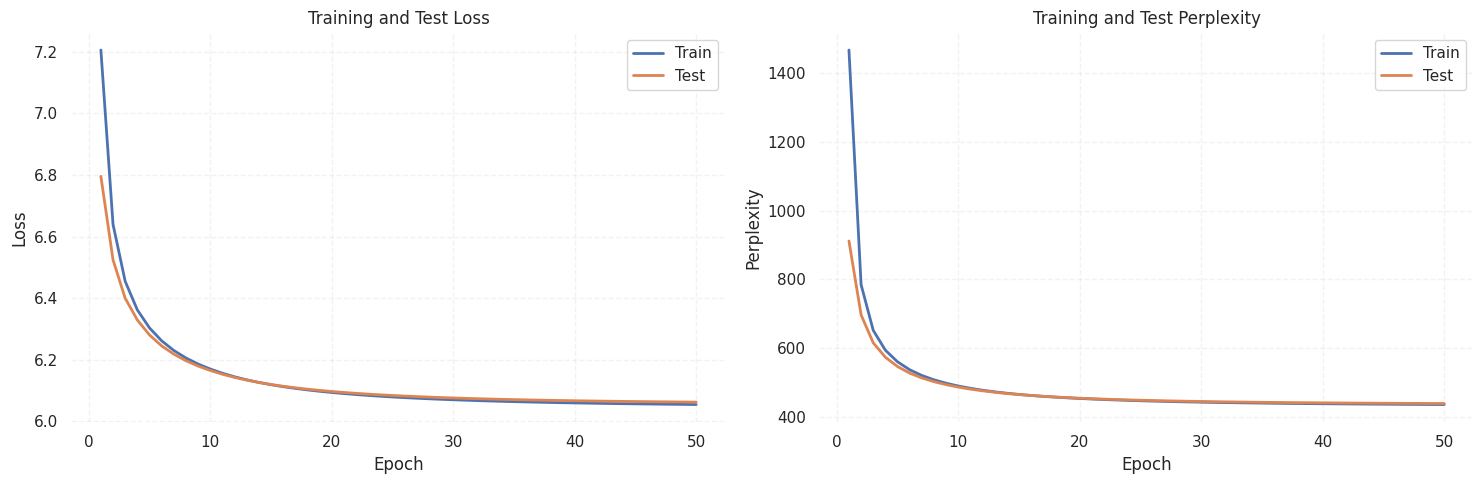

In [54]:
# Plot training and validation metrics
plot_training_metrics(train_metrics, test_metrics)

---

From the inspection of the plots we can be partially satisfied. The trend of loss and perplexity indicate that the all the part of the trainig phase are correctly implemented an the model is learning from the training data without apparently ovefitting improving its confidence in the next token prediction (obtaining a more concentrated probability distribution). 

However, their value still remains globally high, leaving us to assume that the model will probably have a very poor performance in the phase of autoregressive generation (result quite expected given the complexity of the task and the very simplified model)

---

### Exercise 2: Autoregressive generation (3 points)

For this exercise, run the trained model in an autoregressive fashion and show some examples of generated sequences. Note that the details will depend on the specific type of data (e.g., sampling text tokens, sampling pixels as discrete values, sampling pixels from a continuous range of colours, ...). For this, refer also to Section 8.4 of the book.

✍ **DESCRIPTION OF THE CODE**

*Provide a description of what you are implementing, both as text and in the comments of the code. Show some examples of generated sequences.*

---

To test the autoregressive token generation of our model, we chose to take as input the beginning of one of the books present in the dataset (a sequence that had at least a length equal to or greater than that required by the seq_length parameter). For the number of tokens to generate, we decided to take the sentence following the starting sequence, tokenize it, and count how many tokens it corresponded to.

For the actual generation, we proceeded as follows:

1. we encoded the initial input
2. we selected only the last seq_length token_ids
3. we passed this sequence to the model's call function in inference mode, passing the weights obtained from training and the hyperparameters used for it
4. generated the logits for the next token (appropriately influenced by the Temperature parameter)
5. we applied softmax and extracted the next token by sampling from the dictionary using the logits as probability distribution
6. added the predicted next token id to the input sequence
7. repeated steps 2 to 6 for num_predictions times
8. proceeded to decode the initial sequence plus our generated tokens

---

In [66]:
# Encode the starting sequence
init_input_seq = "the year 1866 was signalised by a remarkable incident a mysterious and puzzling phenomenon which doubtless no one has yet forgotten not to mention rumours which agitated the maritime population and excited the public mind even in the interior of continents seafaring men were particularly excited"
initial_tokens = tokenizer.encode(init_input_seq).ids
print(f"- Complete starting input sequence for autoregressive next token generation: \n {init_input_seq}")


- Complete starting input sequence for autoregressive next token generation: 
 the year 1866 was signalised by a remarkable incident a mysterious and puzzling phenomenon which doubtless no one has yet forgotten not to mention rumours which agitated the maritime population and excited the public mind even in the interior of continents seafaring men were particularly excited


In [65]:
real_prediction = "merchants common sailors captains of vessels skippers both of europe and america naval officers of all countries and the governments of several States on the two continents were deeply interested in the matter"
real_next_tokens = tokenizer.encode(real_prediction)
num_predictions = len(real_next_tokens)
print(f"- Number of next token to predict: {num_predictions}\n")
print(f"- Real test that the model should predict:\n{real_prediction}")

- Number of next token to predict: 33

- Real test that the model should predict:
merchants common sailors captains of vessels skippers both of europe and america naval officers of all countries and the governments of several States on the two continents were deeply interested in the matter


In [68]:
generated_tokens = initial_tokens.copy()

key = jax.random.PRNGKey(123)

# Generate 'num_predictions' next tokens
for _ in range(num_predictions): 
    # Take as real input only the last 'seq_length' tokens
    input_sequence = jnp.array(generated_tokens[-seq_length:])

    input_tensor = jnp.array(input_sequence)[None, :] 

    # Model forward pass in inference mode (i.e. no dropout)
    logits = call_lstm_model(
        input_tensor,
        model_params,
        training=False,  
        temperature=0.7,
        num_lstm_layers=num_lstm_layers,
        num_dense_layers=num_dense_layers,
        hidden_size=hidden_size
    )
    # Apply log softmax
    log_probs = jax.nn.log_softmax(logits[1], axis=-1)
    # Sample the next token prediction from the dictionary distribution with probs given by the logits
    key, subkey = jax.random.split(key)
    next_idx = int(jax.random.choice(subkey, jnp.arange(len(log_probs)), p=jnp.exp(log_probs)))

    # Add the next predicted token to the starting text
    generated_tokens.append(next_idx)

# Convert token ids back to tokens
tokens = [tokenizer.id_to_token(tok_id) for tok_id in generated_tokens]

# Join into string
generated_text = ' '.join(tokens)

# Print the complete generated text + initial text encoded and decoded
print(generated_text)

the year [UNK] was [UNK] by a remarkable incident a mysterious and [UNK] phenomenon which doubtless no one has yet forgotten not to mention [UNK] which agitated the [UNK] population and excited the public mind even in the interior of continents [UNK] men were particularly excited perished of alone northward with he a of were could that to enough soon every dog the this that the supplied of brick [UNK] upon fluttered after me it of the and [UNK]


---

From the results, we can notice the following things:

- the UNK tokens that replace some missing words indicate that they were present in the text fewer than 10 times and therefore were grouped under this single special token
- the autoregressive generation works correctly
- the quality of generation is consistent with the loss and perplexity values obtained, highlighting how the model would primarily need many more training epochs and probably a more complex structure suited to handle this type of problem, such as perhaps a transformer

---

### Exercise 3: Beam search (5 points)

**This exercise is required only for students that have not submitted the first homework, or for students who want to raise their mid-term mark (mark <= 8/10). For a mark of 8/10 or higher, an additional point can also be recovered during the exam.**

> **To recap**: if you submitted the mid-term homework, implement only Exercises 1&2, for a total of *10 points*. If you did not submit the mid-term homework, implement Exercises 1&2&3 for a total of *15 points*.

In standard autoregressive modeling, at every iteration you sample the element with the highest associated probability (e.g., the $\arg\max$ for a discrete distribution). This is known as **greedy decoding**. However, this may result in completed sequences with low probability.

A common modification is **beam search** ([link](https://d2l.ai/chapter_recurrent-modern/beam-search.html)), where at every iteration we keep track of $k$ possible sequences (called **beams**). See also Section 8.4.2 in the book.

**TODO**: For this exercise, implement a beam search decoding procedure for your model, and show some examples of generation, comparing them to the result of greedy decoding.

In [ ]:
# TODO: Your code here.

### Final checklist

1. Carefully check all textual descriptions and the code. Insert comments when needed. <ins>Check for TODO to see if you missed anything.</ins>
2. Run everything one final time. *Please do not send me notebooks with errors or cells that are not working.*
3. Send the completed notebook following the instructions on top.

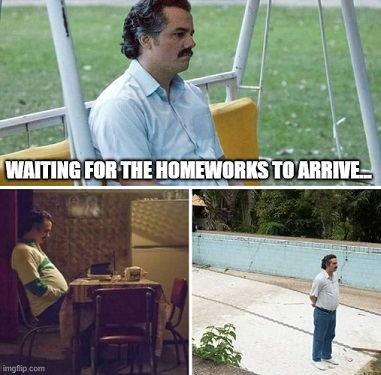